## Download ESC-50 Dataset

The ESC-50 dataset contains 2,000 environmental audio recordings suitable for benchmarking methods of environmental sound classification. Each recording is 5 seconds long and belongs to one of 50 semantic classes.

In [1]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import fft, fftfreq
from scipy.fftpack import dct
import warnings
warnings.filterwarnings('ignore')

URL = "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip"
ZIP_NAME = "ESC-50.zip"
DIR_NAME = "ESC-50-master"

if not os.path.exists(DIR_NAME):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        z.extractall(".")
    os.remove(ZIP_NAME)

DATA_PATH = os.path.join(DIR_NAME, "audio")
df = pd.read_csv(os.path.join(DIR_NAME, "meta/esc50.csv"))
print(f"Dataset Loaded: {len(df)} samples, {df['target'].nunique()} classes.")

Dataset Loaded: 2000 samples, 50 classes.


## Load and Visualize Waveform

A waveform shows the amplitude of an audio signal over time. We'll load a sample audio file and visualize both the full waveform and a zoomed-in section to see individual sample points.

Sample Rate: 44100 Hz
Duration: 5.00 seconds
Total Samples: 220500


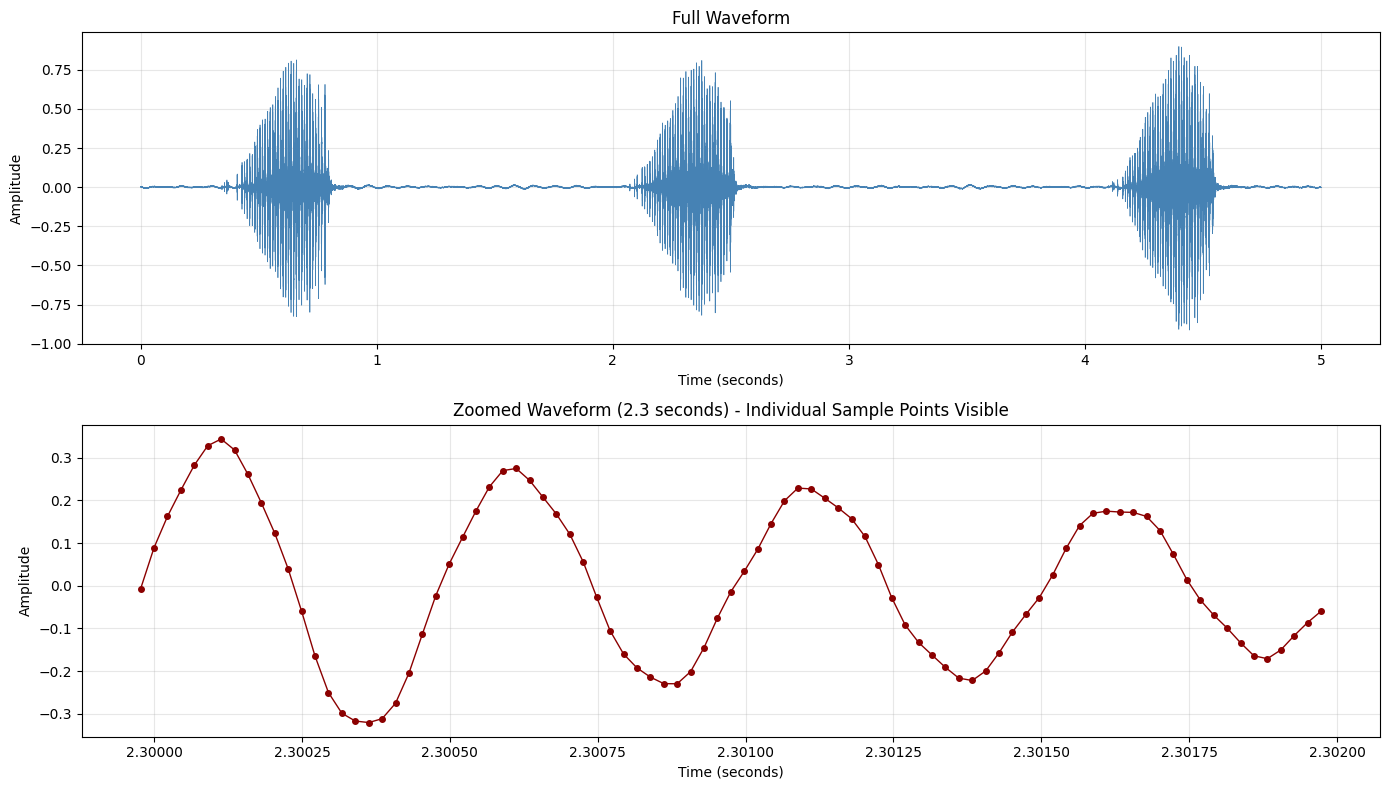

In [13]:
# Load a sample audio file
sample_file = os.path.join(DATA_PATH, df.iloc[45]['filename'])
y, sr = librosa.load(sample_file, sr=None)

print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")
print(f"Total Samples: {len(y)}")

# Create time array
time = np.arange(len(y)) / sr

# Plot full waveform and zoomed section
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full waveform
axes[0].plot(time, y, color='steelblue', linewidth=0.5)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Full Waveform')
axes[0].grid(True, alpha=0.3)

# Zoomed section showing individual points
zoom_start = int(2.3 * sr)
zoom_end = int(2.302 * sr)
time_zoom = time[zoom_start:zoom_end]
y_zoom = y[zoom_start:zoom_end]

axes[1].plot(time_zoom, y_zoom, color='darkred', marker='o', linewidth=1, markersize=4)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Zoomed Waveform (2.3 seconds) - Individual Sample Points Visible')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize 50 Different Waveforms

Displaying multiple audio samples in a grid helps us understand the variety and patterns in different sound classes. Each waveform is shown in a different color.

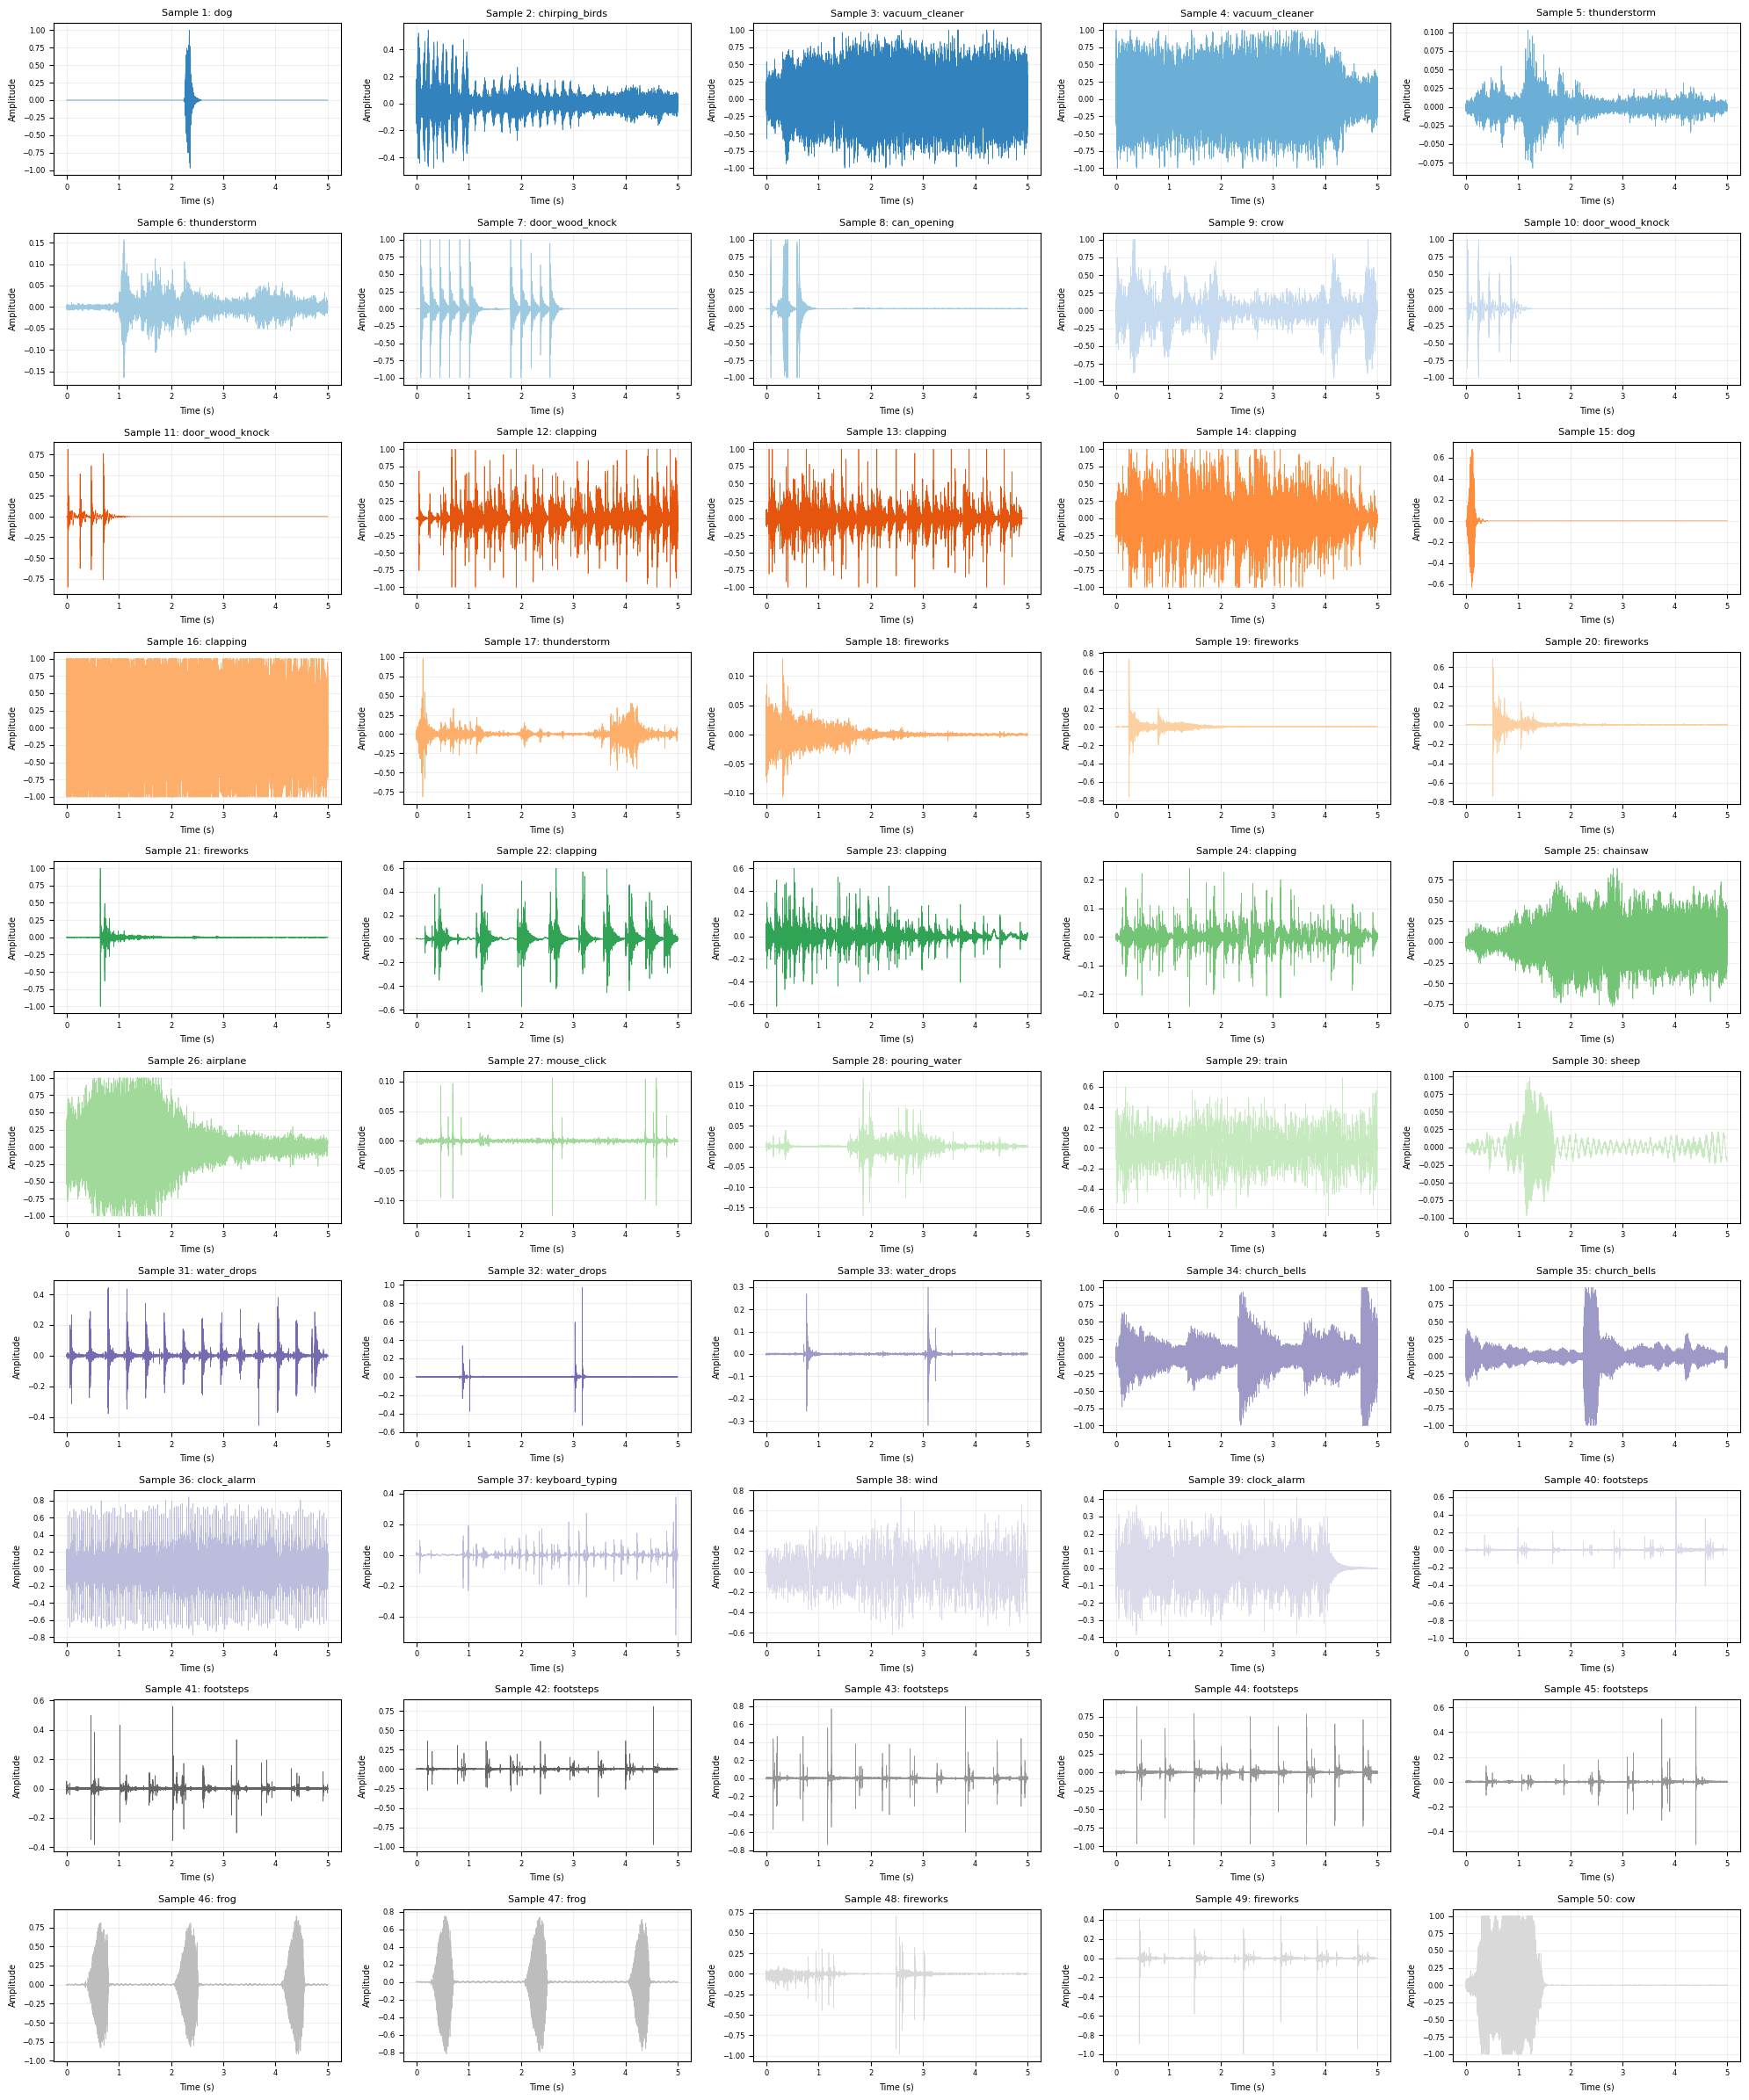

Displayed 50 waveforms from different sound categories.


In [14]:
# Load 50 different audio samples
fig, axes = plt.subplots(10, 5, figsize=(20, 24))
axes = axes.flatten()

# Generate different colors
colors = plt.cm.tab20c(np.linspace(0, 1, 50))

for i in range(50):
    sample_file = os.path.join(DATA_PATH, df.iloc[i]['filename'])
    y_sample, sr_sample = librosa.load(sample_file, sr=None)
    time_sample = np.arange(len(y_sample)) / sr_sample
    
    axes[i].plot(time_sample, y_sample, color=colors[i], linewidth=0.5)
    axes[i].set_title(f"Sample {i+1}: {df.iloc[i]['category']}", fontsize=8)
    axes[i].set_xlabel('Time (s)', fontsize=7)
    axes[i].set_ylabel('Amplitude', fontsize=7)
    axes[i].tick_params(labelsize=6)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Displayed 50 waveforms from different sound categories.")

## Discrete Fourier Transform (DFT)

DFT converts the time-domain signal into frequency domain, showing which frequencies are present in the audio. However, DFT only provides frequency information and loses all temporal (time) information - we cannot tell when each frequency occurred in the signal.

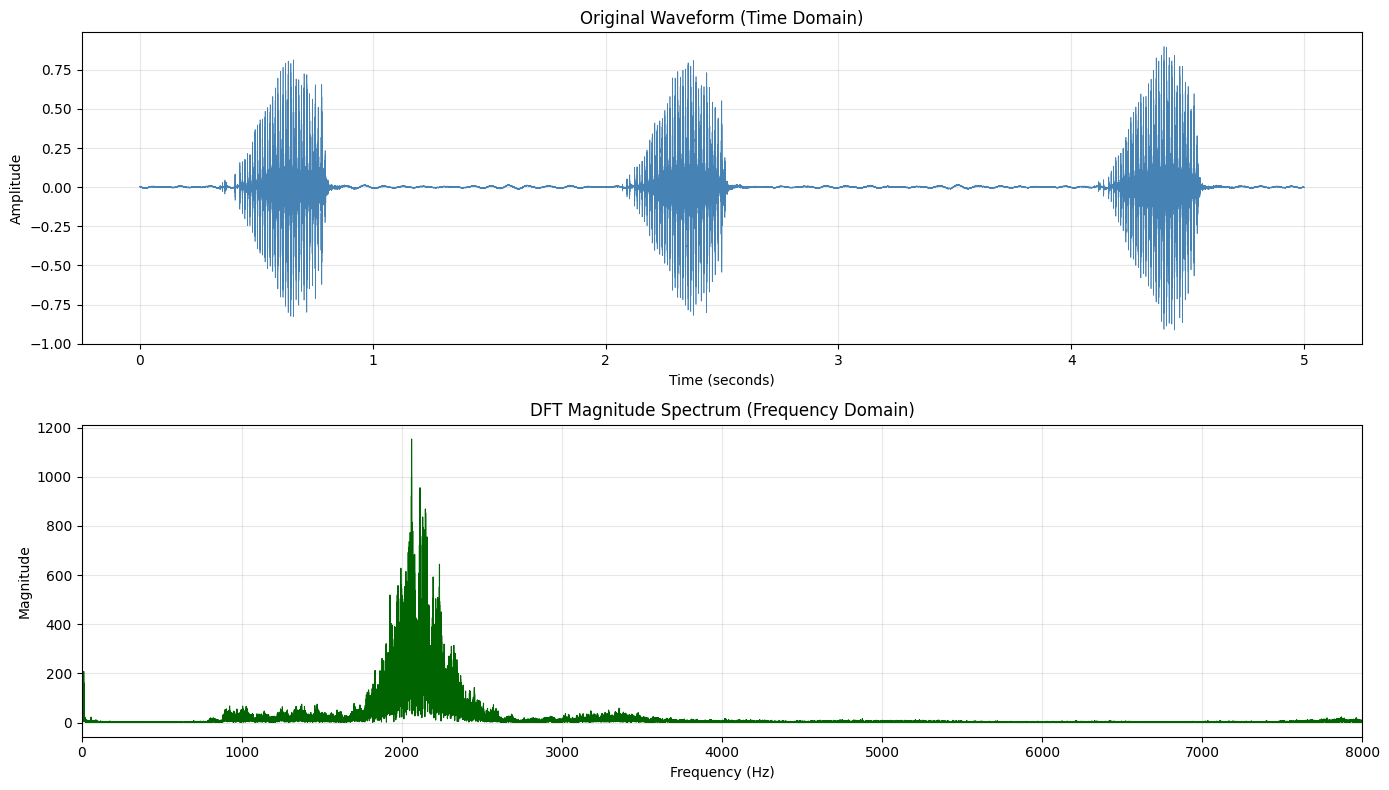


 Information Loss: DFT shows WHAT frequencies are present, but not WHEN they occur.
We lose all temporal information - crucial for understanding audio events over time.


In [15]:
# Use the previously loaded audio
dft_result = fft(y)
frequencies = fftfreq(len(y), 1/sr)

# Take only positive frequencies
positive_freq_idx = frequencies > 0
freq_positive = frequencies[positive_freq_idx]
dft_magnitude = np.abs(dft_result[positive_freq_idx])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original waveform
axes[0].plot(time, y, color='steelblue', linewidth=0.5)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Original Waveform (Time Domain)')
axes[0].grid(True, alpha=0.3)

# DFT magnitude spectrum
axes[1].plot(freq_positive, dft_magnitude, color='darkgreen', linewidth=0.8)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('DFT Magnitude Spectrum (Frequency Domain)')
axes[1].set_xlim(0, 8000)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Information Loss: DFT shows WHAT frequencies are present, but not WHEN they occur.")
print("We lose all temporal information - crucial for understanding audio events over time.")

## Fast Fourier Transform (FFT)

FFT is an efficient algorithm to compute DFT. Like DFT, it provides frequency information but lacks time resolution. For audio analysis, we need to know both WHAT frequencies exist AND WHEN they occur - FFT alone is insufficient for this.

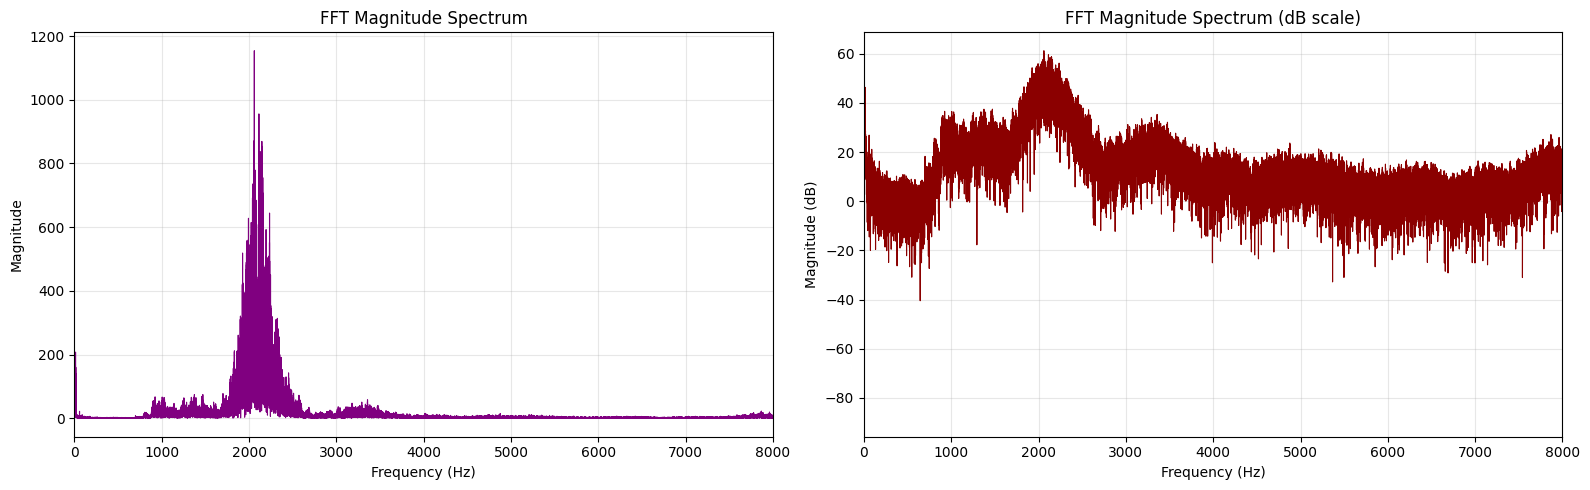


 FFT Limitation: Still no temporal resolution!
We can see frequency content but cannot distinguish between:
  - A dog bark at 1 second vs 3 seconds
  - Sequential sounds vs simultaneous sounds

For audio analysis, we need TIME-FREQUENCY representation!


In [16]:
# Compute FFT
fft_result = np.fft.fft(y)
fft_magnitude = np.abs(fft_result)
fft_freq = np.fft.fftfreq(len(y), 1/sr)

# Take positive frequencies only
positive_mask = fft_freq >= 0
fft_freq_pos = fft_freq[positive_mask]
fft_mag_pos = fft_magnitude[positive_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FFT Magnitude
axes[0].plot(fft_freq_pos, fft_mag_pos, color='purple', linewidth=0.8)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('FFT Magnitude Spectrum')
axes[0].set_xlim(0, 8000)
axes[0].grid(True, alpha=0.3)

# FFT in dB scale
fft_db = 20 * np.log10(fft_mag_pos + 1e-10)
axes[1].plot(fft_freq_pos, fft_db, color='darkred', linewidth=0.8)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('FFT Magnitude Spectrum (dB scale)')
axes[1].set_xlim(0, 8000)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n FFT Limitation: Still no temporal resolution!")
print("We can see frequency content but cannot distinguish between:")
print("  - A dog bark at 1 second vs 3 seconds")
print("  - Sequential sounds vs simultaneous sounds")
print("\nFor audio analysis, we need TIME-FREQUENCY representation!")

## Short-Time Fourier Transform (STFT)

STFT solves the FFT limitation by computing FFT on small overlapping windows of the signal. This gives us BOTH time and frequency information. We can now see which frequencies occur at which times, preserving audio information much better than FFT.

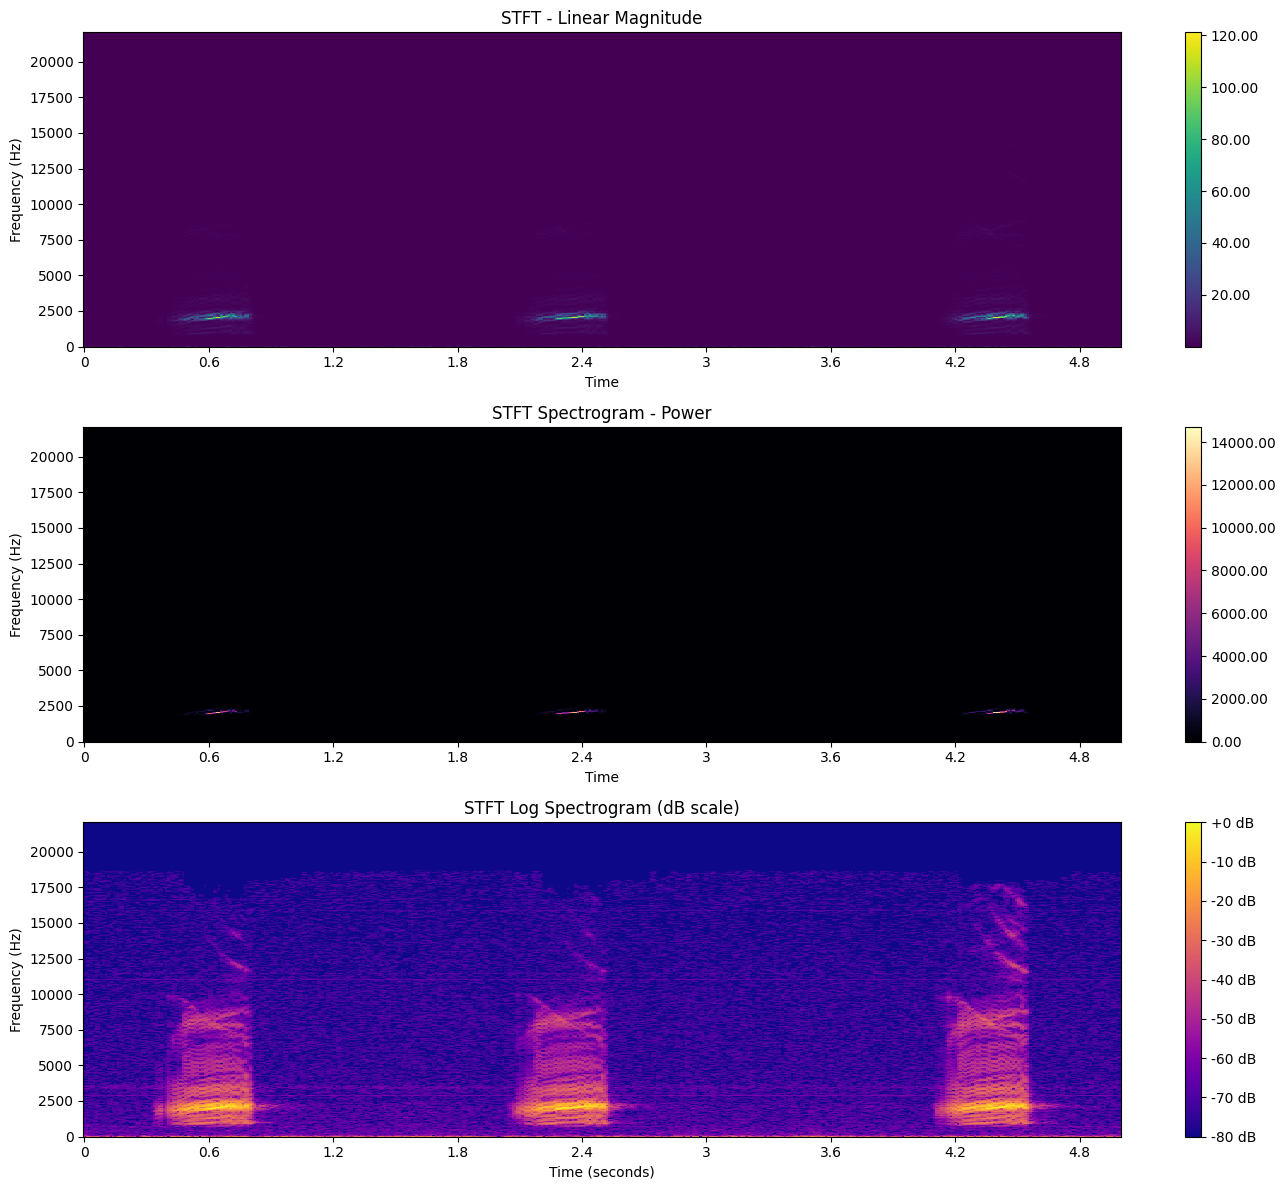


✓ STFT Shape: (1025, 431)
  - Frequency bins: 1025
  - Time frames: 431

✓ Information Retained: Unlike FFT, STFT preserves BOTH:
  1. Frequency content (vertical axis)
  2. Time evolution (horizontal axis)
  3. We can now see when different frequencies occur in the audio!


In [17]:
# Compute STFT
stft_result = librosa.stft(y, n_fft=2048, hop_length=512)
stft_magnitude = np.abs(stft_result)
stft_db = librosa.amplitude_to_db(stft_magnitude, ref=np.max)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. STFT Magnitude (Linear scale)
im1 = librosa.display.specshow(stft_magnitude, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=axes[0], cmap='viridis')
axes[0].set_title('STFT - Linear Magnitude')
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(im1, ax=axes[0], format='%0.2f')

# 2. STFT Spectrogram (Power)
stft_power = stft_magnitude ** 2
im2 = librosa.display.specshow(stft_power, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title('STFT Spectrogram - Power')
axes[1].set_ylabel('Frequency (Hz)')
fig.colorbar(im2, ax=axes[1], format='%0.2f')

# 3. STFT Log Spectrogram (dB scale)
im3 = librosa.display.specshow(stft_db, sr=sr, hop_length=512, x_axis='time', y_axis='hz', ax=axes[2], cmap='plasma')
axes[2].set_title('STFT Log Spectrogram (dB scale)')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_xlabel('Time (seconds)')
fig.colorbar(im3, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print(f"\n✓ STFT Shape: {stft_result.shape}")
print(f"  - Frequency bins: {stft_result.shape[0]}")
print(f"  - Time frames: {stft_result.shape[1]}")
print("\n✓ Information Retained: Unlike FFT, STFT preserves BOTH:")
print("  1. Frequency content (vertical axis)")
print("  2. Time evolution (horizontal axis)")
print("  3. We can now see when different frequencies occur in the audio!")

## Mel Spectrogram

Mel spectrogram converts frequency to the mel scale, which better matches human perception of sound. Low frequencies get more resolution (where humans are more sensitive), high frequencies get less. This makes it ideal for audio classification tasks as it captures perceptually relevant information more efficiently.

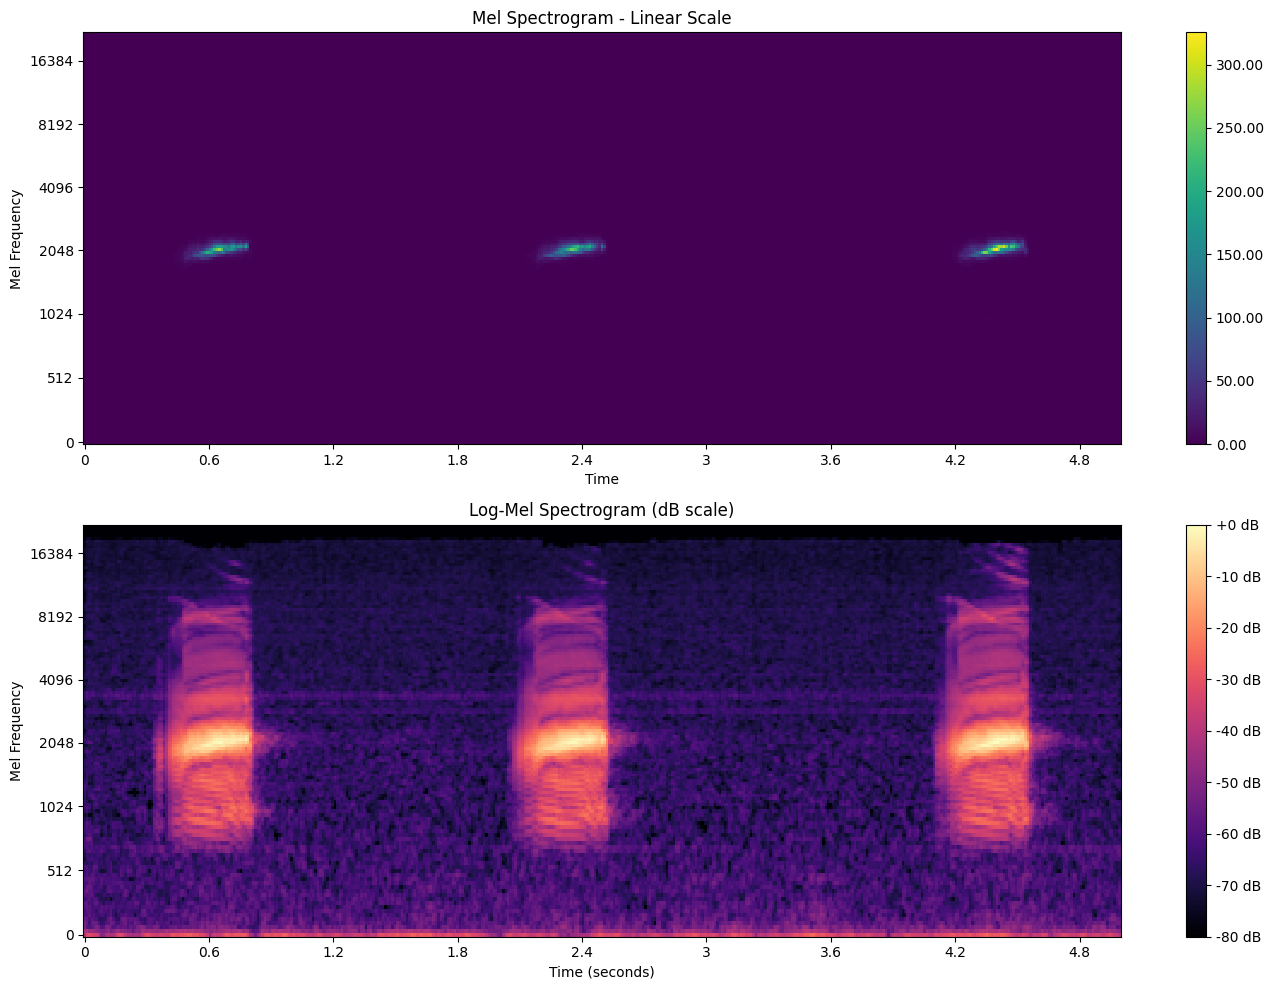


Mel Spectrogram Shape: (128, 431)
  - Mel bins: 128
  - Time frames: 431

✓ Why Mel Spectrogram is Best for Audio Classification:
  1. Perceptually motivated - matches human hearing
  2. More compact than STFT (fewer frequency bins needed)
  3. Better resolution where it matters (low frequencies)
  4. Widely used in deep learning for audio tasks
  5. Reduces dimensionality while preserving important information


In [18]:
# Compute Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Mel Spectrogram (Linear scale)
im1 = librosa.display.specshow(mel_spec, sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=axes[0], cmap='viridis')
axes[0].set_title('Mel Spectrogram - Linear Scale')
axes[0].set_ylabel('Mel Frequency')
fig.colorbar(im1, ax=axes[0], format='%0.2f')

# 2. Log-Mel Spectrogram (dB scale)
im2 = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title('Log-Mel Spectrogram (dB scale)')
axes[1].set_ylabel('Mel Frequency')
axes[1].set_xlabel('Time (seconds)')
fig.colorbar(im2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print(f"\nMel Spectrogram Shape: {mel_spec.shape}")
print(f"  - Mel bins: {mel_spec.shape[0]}")
print(f"  - Time frames: {mel_spec.shape[1]}")
print("\n✓ Why Mel Spectrogram is Best for Audio Classification:")
print("  1. Perceptually motivated - matches human hearing")
print("  2. More compact than STFT (fewer frequency bins needed)")
print("  3. Better resolution where it matters (low frequencies)")
print("  4. Widely used in deep learning for audio tasks")
print("  5. Reduces dimensionality while preserving important information")

## Impact of Different Parameters on Log-Mel Spectrogram

Choosing the right parameters (n_fft/window size, hop_length, n_mels) is crucial. Too low resolution loses important details; too high creates unnecessary computation and may include noise. Let's visualize how different settings affect the spectrogram.

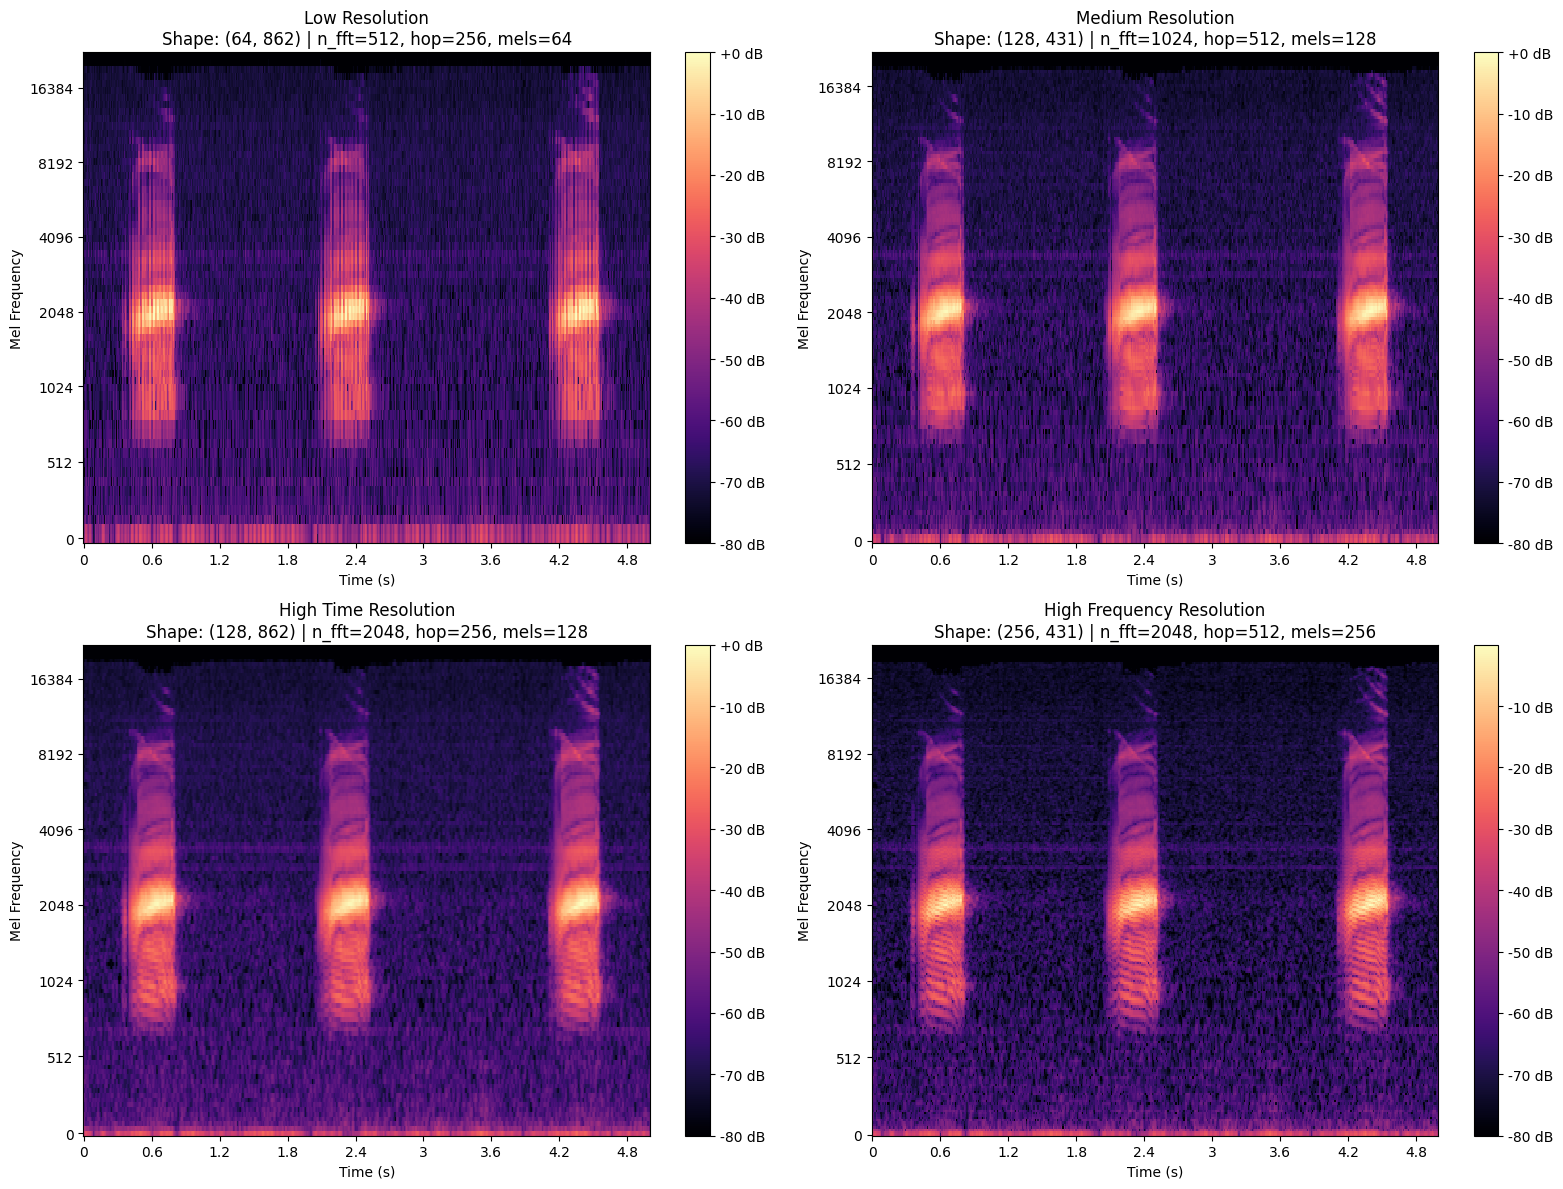


 Parameter Selection Guidelines:
  - n_fft (window size): Larger = better frequency resolution, worse time resolution
  - hop_length (stride): Smaller = better time resolution, more computation
  - n_mels: More bins = more detail, more features, larger data

✓ Common choices for audio classification:
  - n_fft: 1024 or 2048
  - hop_length: 512 (good balance)
  - n_mels: 128 or 256 (sufficient for most tasks)


In [19]:
# Define different parameter combinations
configs = [
    {'n_fft': 512, 'hop_length': 256, 'n_mels': 64, 'title': 'Low Resolution'},
    {'n_fft': 1024, 'hop_length': 512, 'n_mels': 128, 'title': 'Medium Resolution'},
    {'n_fft': 2048, 'hop_length': 256, 'n_mels': 128, 'title': 'High Time Resolution'},
    {'n_fft': 2048, 'hop_length': 512, 'n_mels': 256, 'title': 'High Frequency Resolution'}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, config in enumerate(configs):
    # Compute mel spectrogram with specific parameters
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, 
        n_fft=config['n_fft'], 
        hop_length=config['hop_length'], 
        n_mels=config['n_mels']
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Visualize
    im = librosa.display.specshow(
        mel_db, sr=sr, 
        hop_length=config['hop_length'], 
        x_axis='time', y_axis='mel', 
        ax=axes[idx], cmap='magma'
    )
    
    axes[idx].set_title(
        f"{config['title']}\n" 
        f"Shape: {mel_db.shape} | "
        f"n_fft={config['n_fft']}, hop={config['hop_length']}, mels={config['n_mels']}"
    )
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel('Mel Frequency')
    fig.colorbar(im, ax=axes[idx], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("\n Parameter Selection Guidelines:")
print("  - n_fft (window size): Larger = better frequency resolution, worse time resolution")
print("  - hop_length (stride): Smaller = better time resolution, more computation")
print("  - n_mels: More bins = more detail, more features, larger data")
print("\n✓ Common choices for audio classification:")
print("  - n_fft: 1024 or 2048")
print("  - hop_length: 512 (good balance)")
print("  - n_mels: 128 or 256 (sufficient for most tasks)")

## Generate and Save 2000 Log-Mel Spectrograms

We'll process all 2000 audio files in the dataset, compute their log-mel spectrograms, and save them as images. Each spectrogram image will have the same filename as the original audio file for easy mapping.

In [20]:
# Create output directory
output_dir = "SpectogramImages"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# Parameters for spectrogram generation
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

# Generate spectrograms for all files
print(f"\nGenerating {len(df)} spectrograms...")
for idx, row in df.iterrows():
    # Load audio file
    audio_path = os.path.join(DATA_PATH, row['filename'])
    y_audio, sr_audio = librosa.load(audio_path, sr=None)
    
    # Compute log-mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y_audio, sr=sr_audio, 
        n_fft=N_FFT, 
        hop_length=HOP_LENGTH, 
        n_mels=N_MELS
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Save as image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec_db, sr=sr_audio, hop_length=HOP_LENGTH, 
                             x_axis='time', y_axis='mel', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Log-Mel Spectrogram: {row['category']}")
    plt.tight_layout()
    
    # Save with same filename (change extension to .png)
    output_filename = row['filename'].replace('.wav', '.png')
    output_path = os.path.join(output_dir, output_filename)
    plt.savefig(output_path, dpi=100, bbox_inches='tight')
    plt.close()
    
    # Progress update every 100 files
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(df)} files...")

print(f"\n✓ Successfully saved {len(df)} spectrograms to '{output_dir}/' directory.")
print(f"  - Parameters: n_fft={N_FFT}, hop_length={HOP_LENGTH}, n_mels={N_MELS}")
print(f"  - Each image corresponds to its original audio filename.")

Created directory: SpectogramImages

Generating 2000 spectrograms...
  Processed 100/2000 files...
  Processed 200/2000 files...
  Processed 300/2000 files...
  Processed 400/2000 files...
  Processed 500/2000 files...
  Processed 600/2000 files...
  Processed 700/2000 files...
  Processed 800/2000 files...
  Processed 900/2000 files...
  Processed 1000/2000 files...
  Processed 1100/2000 files...
  Processed 1200/2000 files...
  Processed 1300/2000 files...
  Processed 1400/2000 files...
  Processed 1500/2000 files...
  Processed 1600/2000 files...
  Processed 1700/2000 files...
  Processed 1800/2000 files...
  Processed 1900/2000 files...
  Processed 2000/2000 files...

✓ Successfully saved 2000 spectrograms to 'SpectogramImages/' directory.
  - Parameters: n_fft=2048, hop_length=512, n_mels=128
  - Each image corresponds to its original audio filename.


## MFCC, Delta, and Delta-Delta Features

Mel-Frequency Cepstral Coefficients (MFCCs) capture the spectral envelope of sound. Delta features represent the rate of change (velocity), and delta-deltas represent acceleration. Together, they provide both static and dynamic characteristics of audio, commonly used in speech and audio recognition.

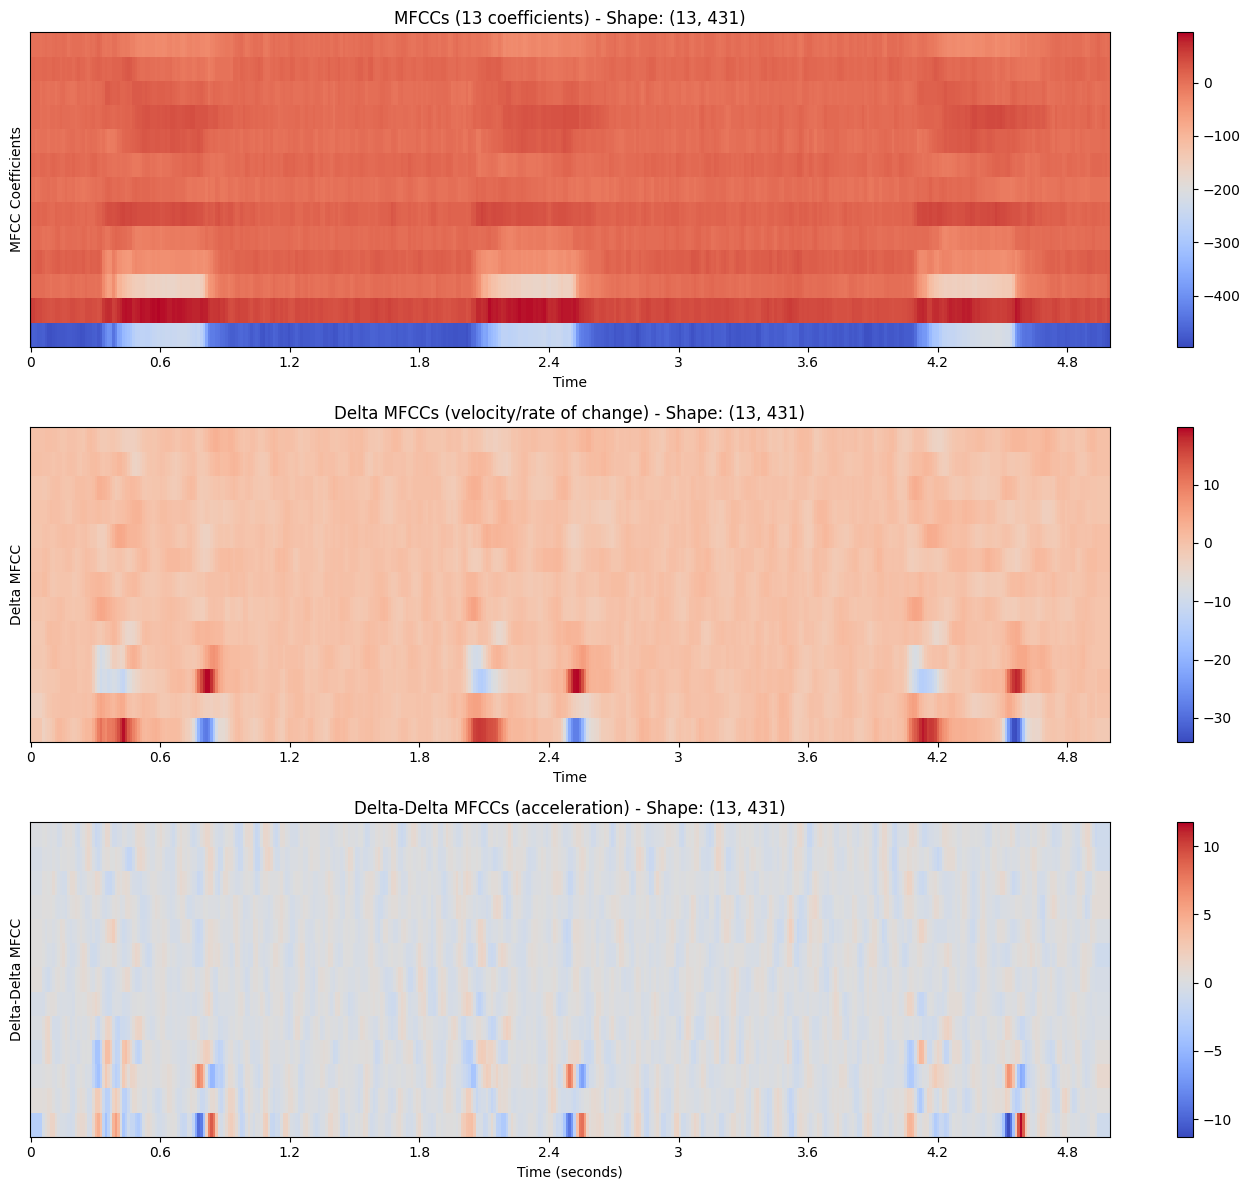


MFCC Feature Summary:
  - MFCCs: (13, 431) (13 coefficients over 431 time frames)
  - Delta MFCCs: (13, 431)
  - Delta-Delta MFCCs: (13, 431)
  - Total features per frame: 39 (13 + 13 + 13)

✓ What each feature captures:
  - MFCCs: Spectral envelope (timbre, sound color)
  - Delta: Temporal dynamics (how sound changes)
  - Delta-Delta: Acceleration of change

These 39 features (13x3) are widely used in traditional audio classification.


In [21]:
# Extract 13 MFCC coefficients
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)

# Compute delta (first derivative)
mfcc_delta = librosa.feature.delta(mfccs)

# Compute delta-delta (second derivative / acceleration)
mfcc_delta2 = librosa.feature.delta(mfccs, order=2)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot MFCCs
im1 = librosa.display.specshow(mfccs, sr=sr, hop_length=512, x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_ylabel('MFCC Coefficients')
axes[0].set_title(f'MFCCs (13 coefficients) - Shape: {mfccs.shape}')
fig.colorbar(im1, ax=axes[0])

# Plot Delta MFCCs
im2 = librosa.display.specshow(mfcc_delta, sr=sr, hop_length=512, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_ylabel('Delta MFCC')
axes[1].set_title(f'Delta MFCCs (velocity/rate of change) - Shape: {mfcc_delta.shape}')
fig.colorbar(im2, ax=axes[1])

# Plot Delta-Delta MFCCs
im3 = librosa.display.specshow(mfcc_delta2, sr=sr, hop_length=512, x_axis='time', ax=axes[2], cmap='coolwarm')
axes[2].set_ylabel('Delta-Delta MFCC')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title(f'Delta-Delta MFCCs (acceleration) - Shape: {mfcc_delta2.shape}')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print("\nMFCC Feature Summary:")
print(f"  - MFCCs: {mfccs.shape} (13 coefficients over {mfccs.shape[1]} time frames)")
print(f"  - Delta MFCCs: {mfcc_delta.shape}")
print(f"  - Delta-Delta MFCCs: {mfcc_delta2.shape}")
print(f"  - Total features per frame: {mfccs.shape[0] * 3} (13 + 13 + 13)")
print("\n✓ What each feature captures:")
print("  - MFCCs: Spectral envelope (timbre, sound color)")
print("  - Delta: Temporal dynamics (how sound changes)")
print("  - Delta-Delta: Acceleration of change")
print("\nThese 39 features (13x3) are widely used in traditional audio classification.")

## Complete DSP Pipeline Visualization

Final visualization comparing all DSP techniques side-by-side for 3 different audio samples. This shows the complete journey from raw waveform through various frequency domain representations, illustrating how each technique captures different aspects of the audio signal.

In [ ]:
# Select 3 different audio samples
sample_indices = [0, 25, 49]

for sample_idx in sample_indices:
    # Load audio
    sample_file = os.path.join(DATA_PATH, df.iloc[sample_idx]['filename'])
    y_sample, sr_sample = librosa.load(sample_file, sr=None)
    time_sample = np.arange(len(y_sample)) / sr_sample
    
    # Compute all transforms
    dft_sample = np.abs(fft(y_sample))
    fft_sample = np.abs(np.fft.fft(y_sample))
    stft_sample = librosa.stft(y_sample, n_fft=2048, hop_length=512)
    stft_db = librosa.amplitude_to_db(np.abs(stft_sample), ref=np.max)
    mel_sample = librosa.feature.melspectrogram(y=y_sample, sr=sr_sample, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel_sample, ref=np.max)
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Waveform
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(time_sample, y_sample, color='steelblue', linewidth=0.5)
    ax1.set_title(f"Sample {sample_idx+1}: {df.iloc[sample_idx]['category']} - Waveform", fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    
    # 2. DFT
    ax2 = fig.add_subplot(gs[1, 0])
    freq_dft = np.fft.fftfreq(len(y_sample), 1/sr_sample)
    positive_freq = freq_dft > 0
    ax2.plot(freq_dft[positive_freq], dft_sample[positive_freq], color='darkgreen', linewidth=0.8)
    ax2.set_title('DFT Magnitude')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.set_xlim(0, 8000)
    ax2.grid(True, alpha=0.3)
    
    # 3. FFT
    ax3 = fig.add_subplot(gs[1, 1])
    freq_fft = np.fft.fftfreq(len(y_sample), 1/sr_sample)
    positive_fft = freq_fft >= 0
    fft_db_plot = 20 * np.log10(fft_sample[positive_fft] + 1e-10)
    ax3.plot(freq_fft[positive_fft], fft_db_plot, color='purple', linewidth=0.8)
    ax3.set_title('FFT Magnitude (dB)')
    ax3.set_xlabel('Frequency (Hz)')
    ax3.set_ylabel('Magnitude (dB)')
    ax3.set_xlim(0, 8000)
    ax3.grid(True, alpha=0.3)
    
    # 4. STFT Spectrogram
    ax4 = fig.add_subplot(gs[2, 0])
    im4 = librosa.display.specshow(stft_db, sr=sr_sample, hop_length=512, x_axis='time', y_axis='hz', ax=ax4, cmap='plasma')
    ax4.set_title('STFT Spectrogram (dB)')
    ax4.set_ylabel('Frequency (Hz)')
    ax4.set_xlabel('Time (s)')
    fig.colorbar(im4, ax=ax4, format='%+2.0f dB')
    
    # 5. Mel Spectrogram
    ax5 = fig.add_subplot(gs[2, 1])
    im5 = librosa.display.specshow(mel_db, sr=sr_sample, hop_length=512, x_axis='time', y_axis='mel', ax=ax5, cmap='magma')
    ax5.set_title('Mel Spectrogram (dB)')
    ax5.set_ylabel('Mel Frequency')
    ax5.set_xlabel('Time (s)')
    fig.colorbar(im5, ax=ax5, format='%+2.0f dB')
    
    plt.suptitle(f"Complete DSP Analysis Pipeline - Sample {sample_idx+1}", fontsize=14, fontweight='bold', y=0.995)
    plt.show()
    print(f"\nProcessed sample {sample_idx+1}: {df.iloc[sample_idx]['filename']} ({df.iloc[sample_idx]['category']})")
    print("="*80)